Importación de librerías y configuración

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Carga y preparación de los datos

In [ ]:
def recopilar_datos_estadisticos(base_dir="results/image/cuda"):
    datos = []
    
    if not os.path.exists(base_dir):
        print(f"La ruta {base_dir} no existe. Comprueba la ubicación del notebook.")
        return pd.DataFrame()
        
    for hw_folder in os.listdir(base_dir):
        hw_path = os.path.join(base_dir, hw_folder)
        if os.path.isdir(hw_path):
            for mode_folder in os.listdir(hw_path):
                mode_path = os.path.join(hw_path, mode_folder)
                if os.path.isdir(mode_path):
                    stats_file = os.path.join(mode_path, "stats.json")
                    if os.path.exists(stats_file):
                        with open(stats_file, 'r') as f:
                            data = json.load(f)

                            config_model_str = data.get("config", {}).get("model", "{}")
                            config_model = json.loads(config_model_str)
                            
                            fila = {
                                "Hardware": hw_folder,
                                "Modo": mode_folder,
                                "Batch_Size": config_model.get("per_device_batch_size", 0),
                                "Tiempo_Total_Segundos": data.get("elapsed_seconds", 0),
                                "Imagenes_por_Segundo": data.get("throughput_images_per_second", 0),
                                "Memoria_RSS_MB": data.get("memory", {}).get("rss_mb", {}).get("max", 0),
                                "Memoria_VRAM_MB": data.get("memory", {}).get("cuda_allocated_mb", {}).get("max", 0)
                            }
                            datos.append(fila)                   
    return pd.DataFrame(datos)

# Cargar los datos y filtrar solo las ejecuciones sin el profiler
# Cargar los datos
df_resultados = recopilar_datos_estadisticos("results/image/cuda")

# Aplicar el filtro para dejar solo las ejecuciones sin profiler
df_resultados = df_resultados[df_resultados['Modo'] == 'no_profile']

display(df_resultados)

,Hardware,Modo,Batch_Size,Tiempo_Total_Segundos,Imagenes_por_Segundo,Memoria_RSS_MB,Memoria_VRAM_MB
0,1xCPU,no_profile,32,21.0880,3.0349,1755.296875,0.000000
2,1xGPU,no_profile,32,3.5386,1109.1873,1558.210938,373.802734
4,24xCPU,no_profile,32,21.0421,3.0415,1755.378906,0.000000
6,24xCPU-Distributed,no_profile,32,21.0210,3.0446,1754.785156,0.000000
8,2xGPU,no_profile,32,3.5749,1097.9411,1541.531250,373.802734
10,2xGPU-Distributed,no_profile,32,1.9770,2007.0385,1917.621094,701.802734
12,3xGPU,no_profile,32,3.5730,1098.5282,1553.289062,373.802734
14,3xGPU-Distributed,no_profile,32,1.2954,3038.4834,2006.500000,701.802734
16,4xGPU,no_profile,32,3.5647,1101.0592,1542.906250,373.802734
18,4xGPU-Distributed,no_profile,32,1.0339,3837.9694,2006.984375,701.802734


Gráfico de Rendimiento

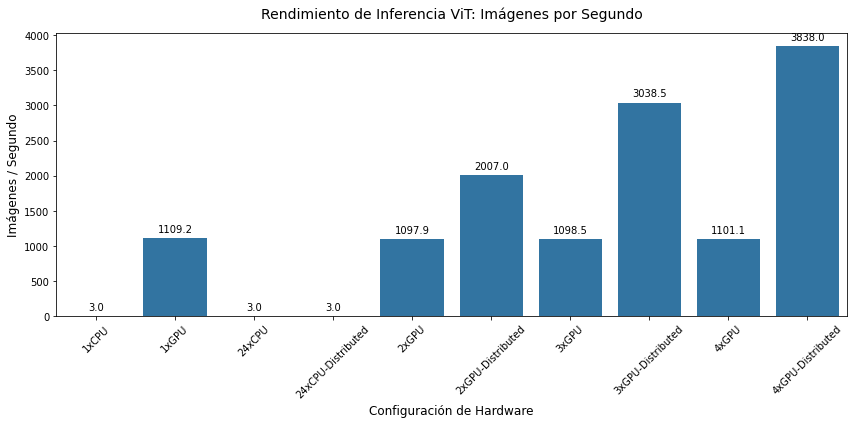

In [11]:
plt.figure(figsize=(12, 6))
barplot1 = sns.barplot(data=df_resultados, x="Hardware", y="Imagenes_por_Segundo")

plt.title('Rendimiento de Inferencia ViT: Imágenes por Segundo', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Imágenes / Segundo', fontsize=12)
plt.xticks(rotation=45)

# Añadir valores numéricos sobre las barras
for p in barplot1.patches:
    barplot1.annotate(format(p.get_height(), '.1f'), 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

Gráfico de Consumo de Memoria

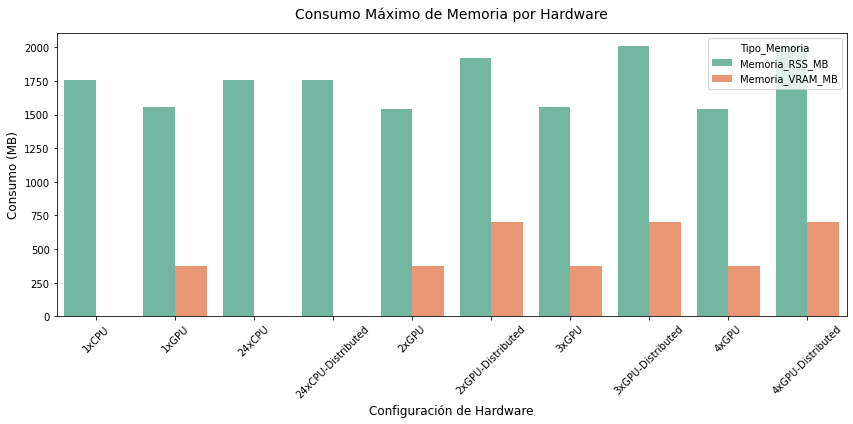

In [ ]:
# Reestructurar la tabla para poder pintar dos barras juntas (RAM y VRAM)
df_memoria = df_resultados.melt(
    id_vars=["Hardware"], 
    value_vars=["Memoria_RSS_MB", "Memoria_VRAM_MB"],
    var_name="Tipo_Memoria", 
    value_name="Consumo_MB"
)

plt.figure(figsize=(12, 6))
barplot2 = sns.barplot(data=df_memoria, x="Hardware", y="Consumo_MB", hue="Tipo_Memoria", palette="Set2")

plt.title('Consumo Máximo de Memoria por Hardware', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Consumo (MB)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Grafica tiempo de ejecución

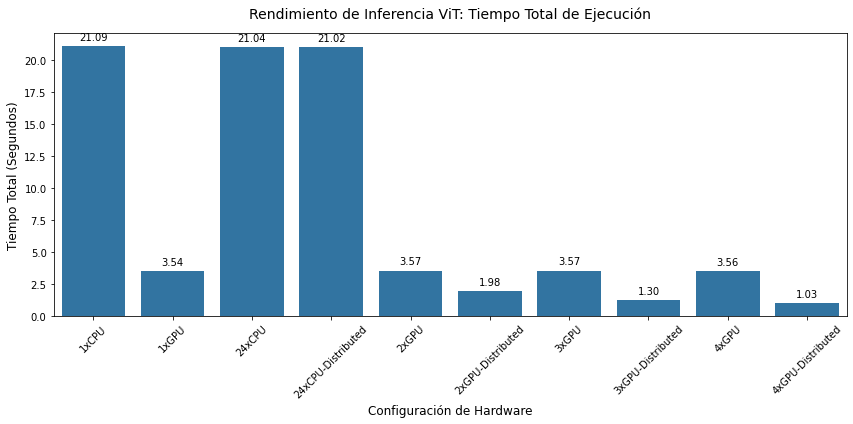

In [17]:
plt.figure(figsize=(12, 6))
# Usamos la columna real Tiempo_Total_Segundos generada en tu dataset
barplot_tiempo = sns.barplot(data=df_resultados, x="Hardware", y="Tiempo_Total_Segundos")

plt.title('Rendimiento de Inferencia ViT: Tiempo Total de Ejecución', fontsize=14, pad=15)
plt.xlabel('Configuración de Hardware', fontsize=12)
plt.ylabel('Tiempo Total (Segundos)', fontsize=12)
plt.xticks(rotation=45)

# Añadir valores numéricos sobre las barras
for p in barplot_tiempo.patches:
    barplot_tiempo.annotate(format(p.get_height(), '.2f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()

Gráfica impacto del tamaño del Batch

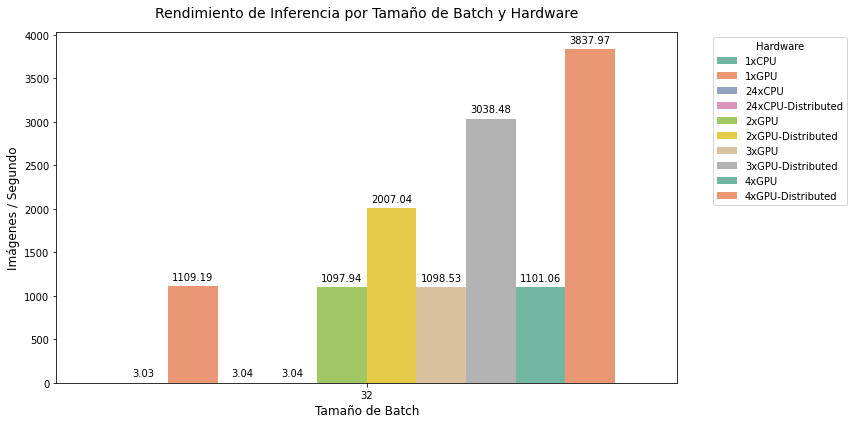

In [19]:
plt.figure(figsize=(12, 6))

# Crear el gráfico de barras agrupado
barplot_batch = sns.barplot(
    data=df_resultados, 
    x="Batch_Size", 
    y="Imagenes_por_Segundo", 
    hue="Hardware", 
    palette="Set2"
)

plt.title('Rendimiento de Inferencia por Tamaño de Batch y Hardware', fontsize=14, pad=15)
plt.xlabel('Tamaño de Batch', fontsize=12)
plt.ylabel('Imágenes / Segundo', fontsize=12)

# Añadir valores numéricos sobre las barras
for p in barplot_batch.patches:
    # Solo anotamos si la barra tiene una altura mayor que 0
    if p.get_height() > 0:
        barplot_batch.annotate(
            format(p.get_height(), '.2f'), 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', 
            va='center', 
            xytext=(0, 9), 
            textcoords='offset points'
        )

# Mover la leyenda fuera del gráfico para que no tape las barras
plt.legend(title='Hardware', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()